# 03 - Analyse Logement

Analyse des enjeux liés au logement social (SRU) et aux loyers sur le territoire.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import DATA_PROCESSED, OUTPUTS

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.size"] = 10

In [2]:
sru = pd.read_parquet(DATA_PROCESSED / "sru.parquet")
sru_dep = pd.read_parquet(DATA_PROCESSED / "sru_par_departement.parquet")
loyers = pd.read_parquet(DATA_PROCESSED / "loyers.parquet")
loyer_dep = pd.read_parquet(DATA_PROCESSED / "loyers_par_departement.parquet")

print(f"SRU: {sru.shape}")
print(f"SRU/dép: {sru_dep.shape}")
print(f"Loyers: {loyers.shape}")
print(f"Loyers/dép: {loyer_dep.shape}")

SRU: (2196, 13)
SRU/dép: (94, 7)
Loyers: (139600, 6)
Loyers/dép: (100, 3)


## 3.1 État des lieux SRU

In [3]:
total_communes = len(sru)
communes_sru = sru["Commune_sru_au_01_01_2025"].sum()
communes_deficitaires = sru["commune_deficitaire"].sum()
communes_carencees = sru["Commune_carencée"].sum()

print(f"Total communes: {total_communes:,}")
print(f"Communes soumises SRU: {communes_sru:,} ({communes_sru/total_communes*100:.1f}%)")
print(f"  Dont déficitaires: {communes_deficitaires:,} ({communes_deficitaires/communes_sru*100:.1f}%)")
print(f"  Dont carencées: {communes_carencees:,} ({communes_carencees/communes_sru*100:.1f}%)")

Total communes: 2,196
Communes soumises SRU: 2,196 (100.0%)
  Dont déficitaires: 1,276 (58.1%)
  Dont carencées: 335 (15.3%)


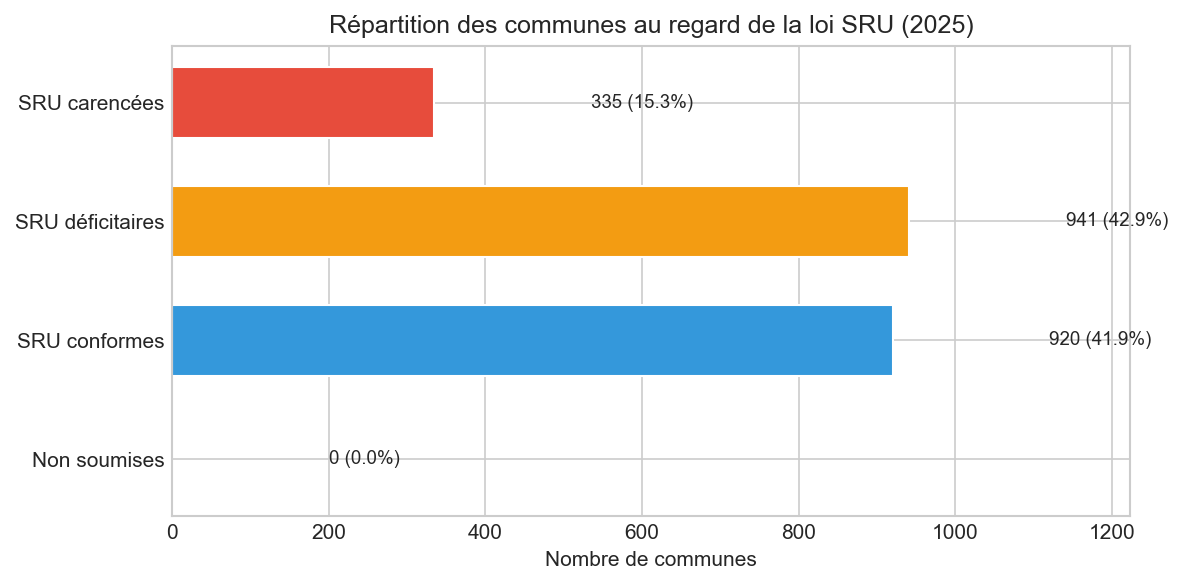

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
categories = ["Non soumises", "SRU conformes", "SRU déficitaires", "SRU carencées"]
values = [
    total_communes - communes_sru,
    communes_sru - communes_deficitaires,
    communes_deficitaires - communes_carencees,
    communes_carencees,
]
colors = ["#2ecc71", "#3498db", "#f39c12", "#e74c3c"]

bars = ax.barh(categories, values, color=colors, edgecolor="white", height=0.6)
ax.set_xlabel("Nombre de communes")
ax.set_title("Répartition des communes au regard de la loi SRU (2025)")
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f"{val:,} ({val/total_communes*100:.1f}%)", va="center", fontsize=9)
ax.set_xlim(0, max(values) * 1.3)
plt.tight_layout()
plt.savefig(OUTPUTS / "01_repartition_sru.png", bbox_inches="tight")
plt.show()

## 3.2 Taux de logement social par département

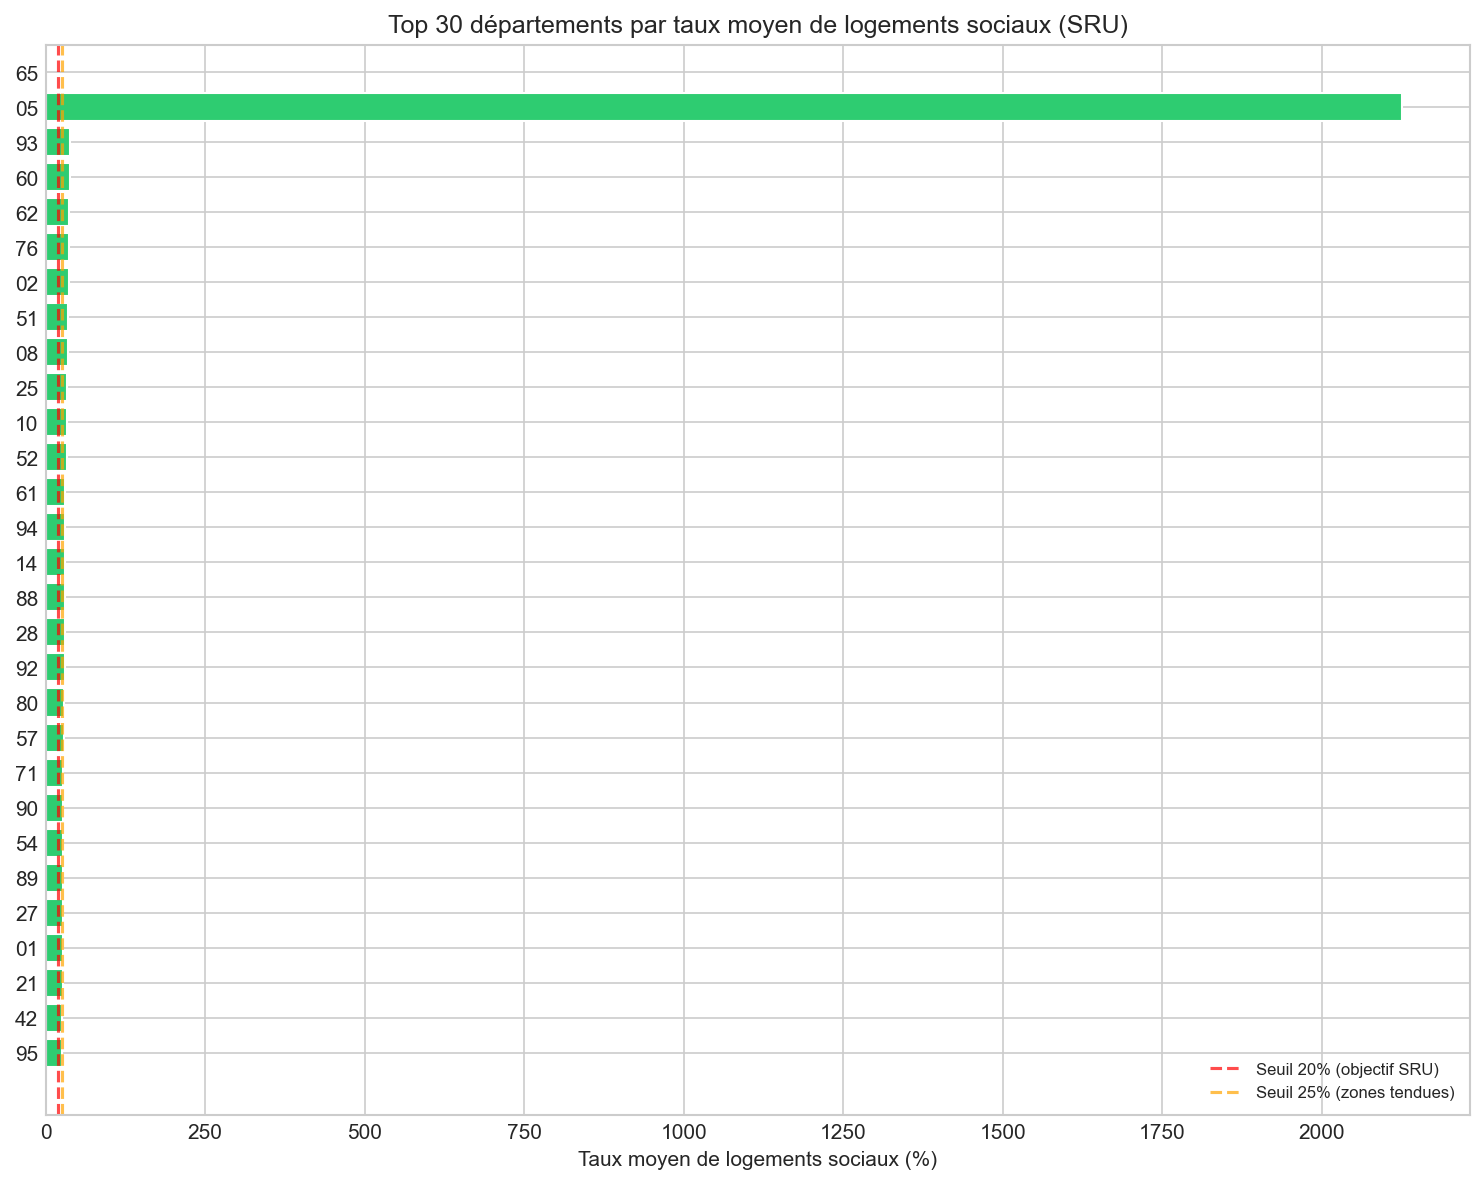

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
top = sru_dep.sort_values("taux_sru_moyen", ascending=True).tail(30)

colors = ["#e74c3c" if v < 20 else "#f39c12" if v < 25 else "#2ecc71" for v in top["taux_sru_moyen"]]
ax.barh(top["code_departement"], top["taux_sru_moyen"], color=colors, edgecolor="white")
ax.axvline(x=20, color="red", linestyle="--", alpha=0.7, label="Seuil 20% (objectif SRU)")
ax.axvline(x=25, color="orange", linestyle="--", alpha=0.7, label="Seuil 25% (zones tendues)")
ax.set_xlabel("Taux moyen de logements sociaux (%)")
ax.set_title("Top 30 départements par taux moyen de logements sociaux (SRU)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUTS / "02_taux_sru_departement.png", bbox_inches="tight")
plt.show()

## 3.3 Loyer moyen par département

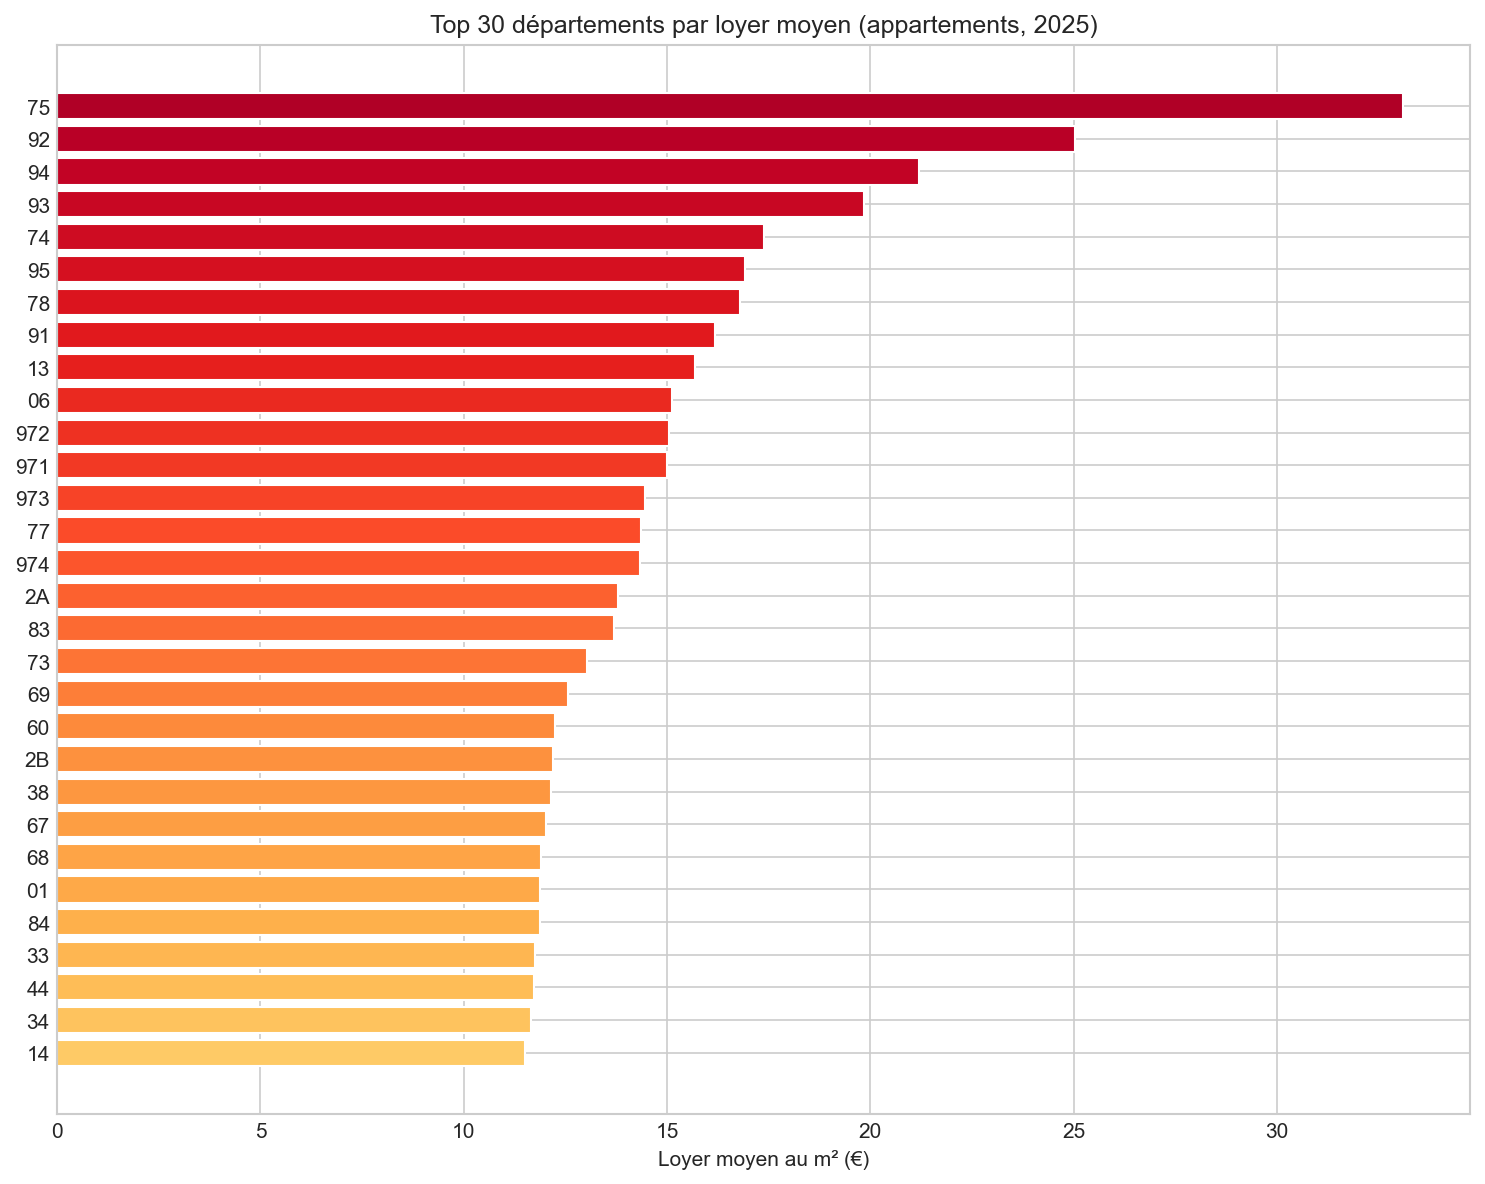

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
top_loyer = loyer_dep.sort_values("loyer_moyen_m2", ascending=True).tail(30)

colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(top_loyer)))
ax.barh(top_loyer["code_departement"], top_loyer["loyer_moyen_m2"], color=colors, edgecolor="white")
ax.set_xlabel("Loyer moyen au m² (€)")
ax.set_title("Top 30 départements par loyer moyen (appartements, 2025)")
plt.tight_layout()
plt.savefig(OUTPUTS / "03_loyer_moyen_departement.png", bbox_inches="tight")
plt.show()

## 3.4 Corrélation loyer vs taux logement social

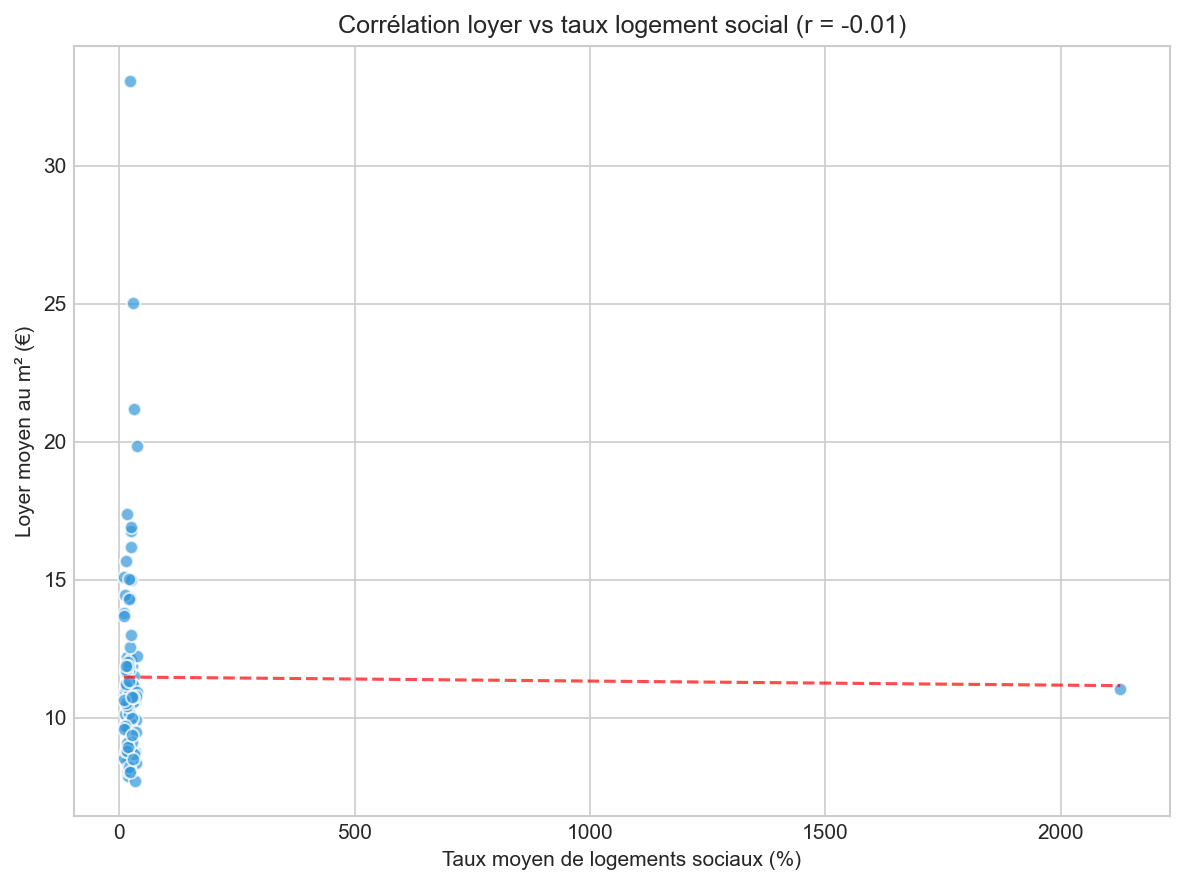

In [7]:
merged = loyer_dep.merge(sru_dep[["code_departement", "taux_sru_moyen"]], on="code_departement", how="inner")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(merged["taux_sru_moyen"], merged["loyer_moyen_m2"], alpha=0.7, s=40, c="#3498db", edgecolors="white")

mask = merged[["taux_sru_moyen", "loyer_moyen_m2"]].dropna()
if len(mask) > 1:
    z = np.polyfit(mask["taux_sru_moyen"], mask["loyer_moyen_m2"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(mask["taux_sru_moyen"].min(), mask["taux_sru_moyen"].max(), 100)
    ax.plot(x_line, p(x_line), "r--", alpha=0.7, linewidth=1.5)

corr = merged[["taux_sru_moyen", "loyer_moyen_m2"]].corr().iloc[0, 1]
ax.set_xlabel("Taux moyen de logements sociaux (%)")
ax.set_ylabel("Loyer moyen au m² (€)")
ax.set_title(f"Corrélation loyer vs taux logement social (r = {corr:.2f})")
plt.tight_layout()
plt.savefig(OUTPUTS / "04_correlation_loyer_sru.png", bbox_inches="tight")
plt.show()

## 3.5 Distribution des loyers par type

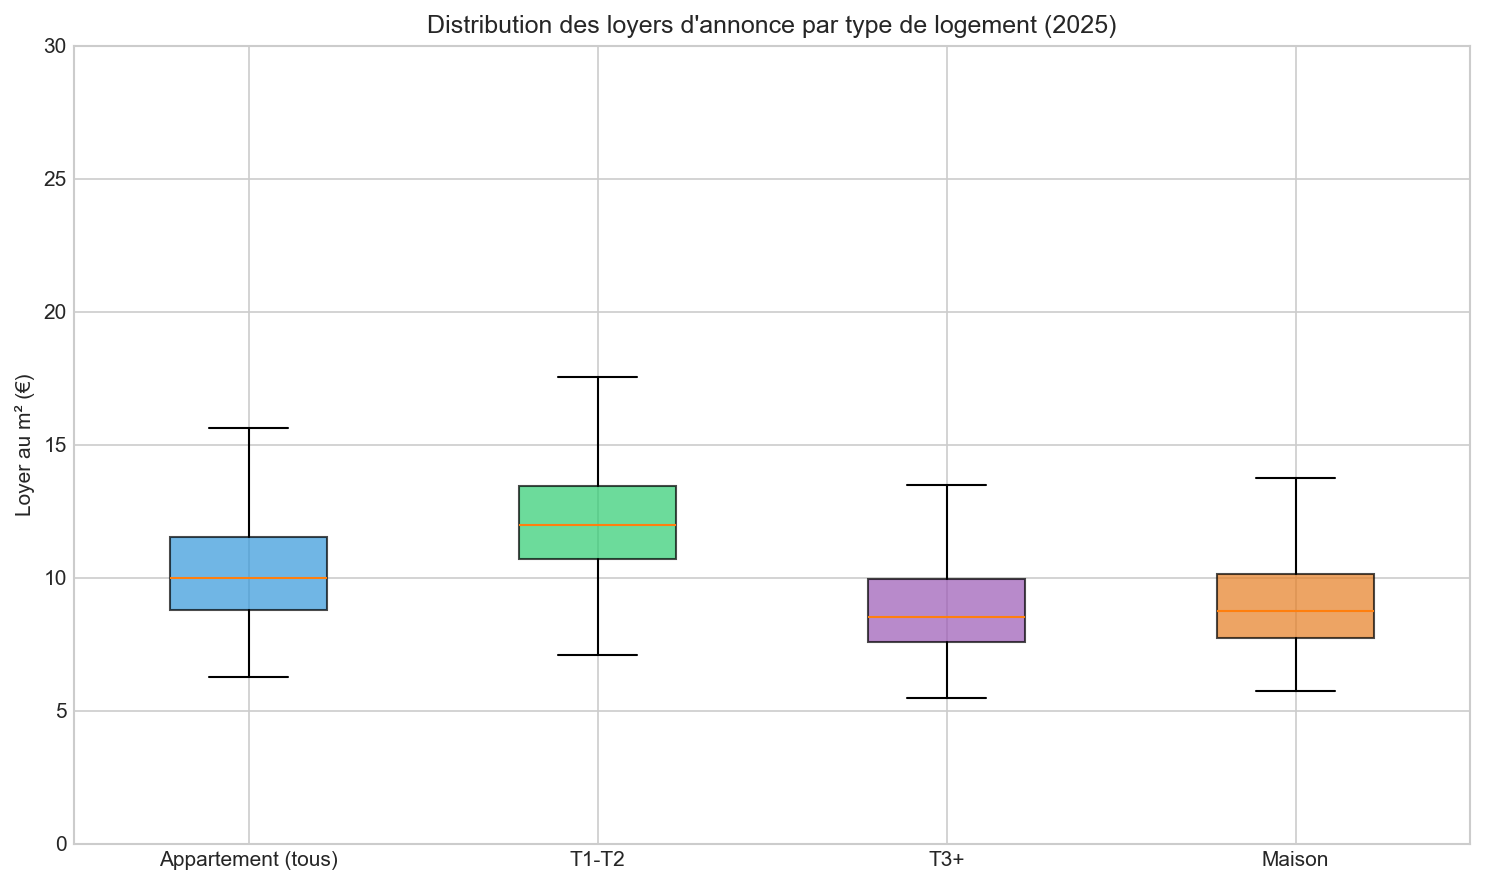

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
types_order = ["appartement", "t1t2", "t3plus", "maison"]
labels = ["Appartement (tous)", "T1-T2", "T3+", "Maison"]

data_by_type = [loyers[loyers["type_logement"] == t]["loypredm2"].dropna() for t in types_order]

bp = ax.boxplot(data_by_type, tick_labels=labels, patch_artist=True, showfliers=False)
colors_box = ["#3498db", "#2ecc71", "#9b59b6", "#e67e22"]
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("Loyer au m² (€)")
ax.set_title("Distribution des loyers d'annonce par type de logement (2025)")
ax.set_ylim(0, 30)
plt.tight_layout()
plt.savefig(OUTPUTS / "05_distribution_loyers_type.png", bbox_inches="tight")
plt.show()

## Synthèse

In [9]:
print("=== SYNTHESE LOGEMENT ===")
print(f"Communes soumises SRU : {communes_sru:,} / {total_communes:,}")
print(f"Communes carencées    : {communes_carencees:,}")
print(f"Loyer moyen France      : {loyers['loypredm2'].mean():.1f} €/m²")
print(f"Loyer médian France     : {loyers['loypredm2'].median():.1f} €/m²")
print(f"Dép. le + cher          : {top_loyer.iloc[-1]['code_departement']} ({top_loyer.iloc[-1]['loyer_moyen_m2']:.1f} €/m²)")
print(f"Dép. le - cher          : {loyer_dep.sort_values('loyer_moyen_m2').iloc[0]['code_departement']} ({loyer_dep.sort_values('loyer_moyen_m2').iloc[0]['loyer_moyen_m2']:.1f} €/m²)")

=== SYNTHESE LOGEMENT ===
Communes soumises SRU : 2,196 / 2,196
Communes carencées    : 335
Loyer moyen France      : 10.3 €/m²
Loyer médian France     : 9.7 €/m²
Dép. le + cher          : 75 (33.1 €/m²)
Dép. le - cher          : 52 (7.7 €/m²)
